# Fase 2 — Análisis exploratorio (EDA)

**Objetivo:** entender la señal *antes* de modelar. Cada hallazgo de este notebook se traduce en una **decisión de diseño** para las siguientes fases:

| Pregunta | Decisión que alimenta |
|---|---|
| ¿Qué ciclos tiene la demanda? | Tamaño de ventana (12/24/48 h) y codificación del calendario |
| ¿Qué variables se relacionan con la demanda? | Selección de features (pregunta 8 del taller) |
| ¿Se parecen los periodos de train, validación y test? | Cómo interpretar las métricas, sobre todo el R² |

> **Regla anti-fuga también en el EDA.** Los gráficos descriptivos usan la serie completa, con las fronteras de los splits marcadas. Pero toda **decisión** (qué variables usar, qué ventana probar) se toma con estadísticas calculadas **solo en entrenamiento**. Si eligiéramos variables mirando el test, estaríamos ajustando el modelo al examen.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf, pacf
from sklearn.feature_selection import mutual_info_regression

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
from graficos import (aplicar_estilo, cmap_secuencial, cmap_divergente,
                      AZUL, NARANJA, AQUA, TINTA_2, REJILLA)
aplicar_estilo()
warnings.filterwarnings("ignore", category=RuntimeWarning)
FIG = RAIZ / "resultados/figuras"

df = pd.read_parquet(RAIZ / "data/processed/dataset_limpio.parquet")
INICIO_VAL, INICIO_TEST = pd.Timestamp("2026-07-01"), pd.Timestamp("2026-10-01")
df["split"] = np.select([df.timestamp < INICIO_VAL, df.timestamp < INICIO_TEST],
                        ["train", "validación"], "test")
train = df[df.split == "train"].copy()

# Para el EDA usamos la demanda con el tratamiento B (sin huecos). y = demanda_objetivo.
df["demanda"] = df["demanda_mw_recuperada"]; train["demanda"] = train["demanda_mw_recuperada"]
print(df.split.value_counts().reindex(["train", "validación", "test"]))

split
train         13104
validación     2208
test           2208
Name: count, dtype: int64


## 1. La serie completa

Primero la vista general. Graficamos la **media diaria** porque 17 520 puntos horarios se verían como una mancha. Las líneas verticales marcan dónde empiezan validación y test.

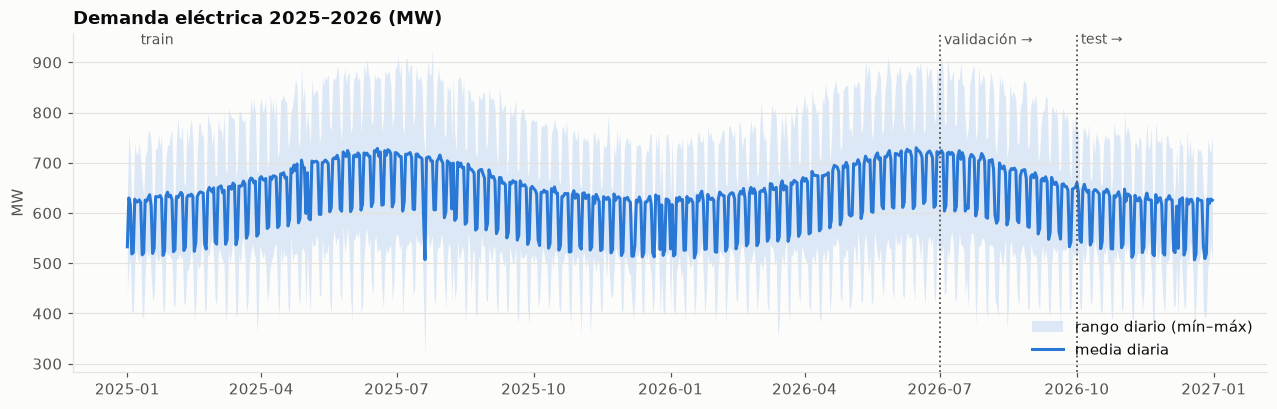

In [2]:
diario = df.set_index("timestamp").demanda_objetivo.resample("D").agg(["mean", "min", "max"])
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(diario.index, diario["min"], diario["max"], color=AZUL, alpha=0.15, linewidth=0,
                label="rango diario (mín–máx)")
ax.plot(diario.index, diario["mean"], color=AZUL, label="media diaria")
for fecha, nombre in [(INICIO_VAL, "validación →"), (INICIO_TEST, "test →")]:
    ax.axvline(fecha, color=TINTA_2, linestyle=":", linewidth=1.2)
    ax.text(fecha, ax.get_ylim()[1], " " + nombre, va="top", color=TINTA_2, fontsize=9)
ax.text(pd.Timestamp("2025-01-10"), ax.get_ylim()[1], "train", va="top", color=TINTA_2, fontsize=9)
ax.set_title("Demanda eléctrica 2025–2026 (MW)"); ax.set_ylabel("MW"); ax.legend(loc="lower right")
plt.savefig(FIG / "02_serie_completa.png"); plt.show()

**Qué vemos:**
- **Estacionalidad anual:** la demanda sube hacia junio–julio y baja en diciembre–enero. Es un sistema dominado por la **refrigeración**: más calor, más aire acondicionado.
- **No hay tendencia** entre años: 2025 y 2026 tienen niveles casi idénticos mes a mes (se verifica abajo). Esto es bueno, porque un modelo entrenado con 2025 sigue siendo válido en 2026.
- **El test cae en la temporada baja (oct–dic).** Esto tiene consecuencias para las métricas (sección 7).
- **La caída brusca de julio de 2025 es real, no un error:** el dataset marca el 2025-07-20 con `festivo = 1`, y ese día además fue **domingo**, así que los dos efectos se suman (507 MW de media, el día más bajo del año). Es otro ejemplo de un valor extremo que la limpieza hizo bien en conservar.

In [3]:
mensual = df.assign(año=df.timestamp.dt.year).pivot_table(index="mes", columns="año",
                                                           values="demanda_objetivo", aggfunc="mean").round(0)
mensual

año,2025,2026
mes,,
1,598.0,594.0
2,608.0,608.0
3,621.0,624.0
4,652.0,652.0
5,672.0,670.0
6,688.0,692.0
7,682.0,684.0
8,653.0,651.0
9,633.0,632.0


## 2. Zoom: dos semanas

A escala horaria aparece el **ciclo diario**, que es lo que la LSTM tendrá que aprender dentro de cada ventana.

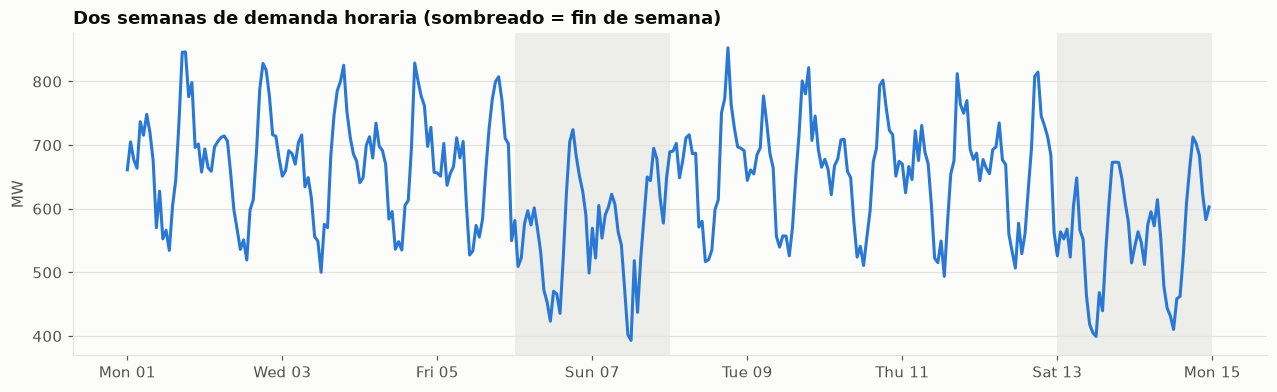

In [4]:
z = df[(df.timestamp >= "2025-09-01") & (df.timestamp < "2025-09-15")]
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(z.timestamp, z.demanda_objetivo, color=AZUL)
for _, fila in z[(z.fin_semana == 1) & (z.hora == 0)].iterrows():
    ax.axvspan(fila.timestamp, fila.timestamp + pd.Timedelta(hours=24), color=REJILLA, alpha=0.6, linewidth=0)
ax.set_title("Dos semanas de demanda horaria (sombreado = fin de semana)"); ax.set_ylabel("MW")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
plt.savefig(FIG / "02_zoom_dos_semanas.png"); plt.show()

Cada día tiene **dos picos**: uno a las 6–7 h y uno más alto a las 19 h. Entre ambos hay un **valle** al mediodía. Los fines de semana la curva entera baja.

## 3. Perfil diario: laboral vs. fin de semana

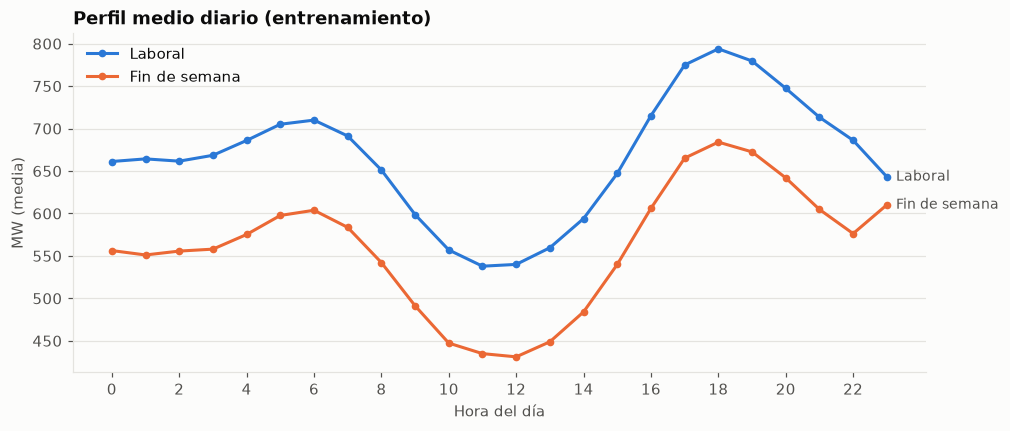

dia_semana
lun    669.0
mar    669.0
mié    667.0
jue    663.0
vie    663.0
sáb    559.0
dom    563.0

Festivo vs normal: {0: 637.3, 1: 554.5} | días festivos en train: 8


,split,fin_semana,demanda_media
fecha,,,
2025-01-01,train,0,533.0
2025-05-01,train,0,599.0
2025-07-20,train,1,507.0
2025-08-07,train,0,608.0
2025-12-08,train,0,535.0
2025-12-25,train,0,527.0
2026-01-01,train,0,529.0
2026-05-01,train,0,597.0
2026-07-20,validación,0,609.0


In [5]:
perfil = train.groupby(["hora", "fin_semana"]).demanda_objetivo.mean().unstack()
fig, ax = plt.subplots(figsize=(10, 4))
for col, color, nombre in [(0, AZUL, "Laboral"), (1, NARANJA, "Fin de semana")]:
    ax.plot(perfil.index, perfil[col], color=color, marker="o", markersize=4, label=nombre)
    ax.annotate(nombre, (23, perfil[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                color=TINTA_2, va="center", fontsize=9)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hora del día"); ax.set_ylabel("MW (media)")
ax.set_title("Perfil medio diario (entrenamiento)"); ax.legend(loc="upper left")
plt.savefig(FIG / "02_perfil_diario.png"); plt.show()

print(train.groupby("dia_semana").demanda_objetivo.mean().round(0).rename(
    {0: "lun", 1: "mar", 2: "mié", 3: "jue", 4: "vie", 5: "sáb", 6: "dom"}).to_string())
print("\nFestivo vs normal:", train.groupby("festivo").demanda_objetivo.mean().round(1).to_dict(),
      "| días festivos en train:", train[train.festivo == 1].timestamp.dt.date.nunique())

fest = (df[df.festivo == 1].assign(fecha=lambda x: x.timestamp.dt.date)
        .groupby("fecha").agg(split=("split", "first"), fin_semana=("fin_semana", "max"),
                              demanda_media=("demanda_objetivo", "mean")).round(0))
fest

**Hallazgos:**
- De lunes a viernes la demanda es casi idéntica (~665 MW). Sábado y domingo caen **~16 %** (~560 MW). La forma del día se mantiene, pero se desplaza hacia abajo.
- Los **festivos** bajan la demanda como un fin de semana, pero hay **solo 8 días festivos en entrenamiento**. El modelo tendrá muy pocos ejemplos para aprender este efecto. Es una **limitación** que anotamos para la pregunta 9.
- El dataset marca **las mismas 6 fechas como festivas cada año** (1-ene, 1-may, 20-jul, 7-ago, 8-dic, 25-dic). No indica a qué país o región corresponde, así que trabajamos con la columna `festivo` tal como viene, sin suponer un calendario externo. El **test incluye dos de esas fechas (8 y 25 de diciembre)**: será interesante ver cómo las predice el modelo.

## 4. Mapa de calor: hora × día de la semana

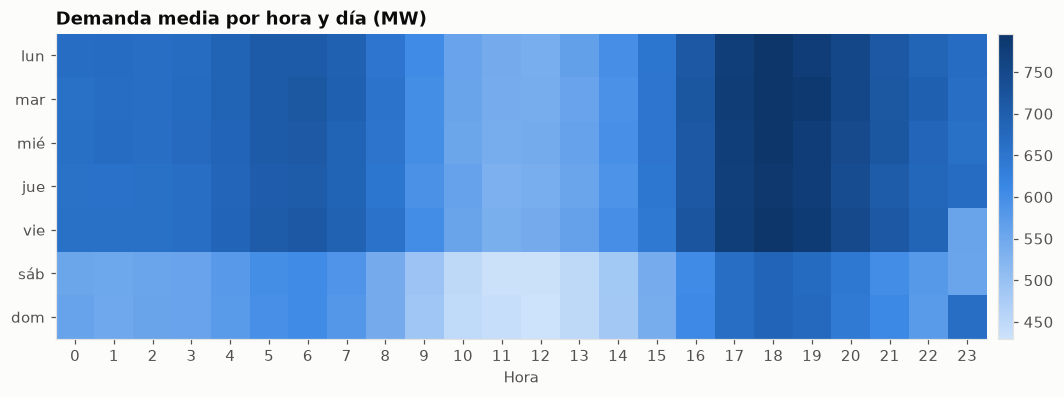

In [6]:
mapa = train.pivot_table(index="dia_semana", columns="hora", values="demanda_objetivo", aggfunc="mean")
fig, ax = plt.subplots(figsize=(13, 3.6))
im = ax.imshow(mapa, aspect="auto", cmap=cmap_secuencial())
ax.set_yticks(range(7), ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
ax.set_xticks(range(24)); ax.set_xlabel("Hora"); ax.grid(False)
ax.set_title("Demanda media por hora y día (MW)")
plt.colorbar(im, ax=ax, pad=0.01)
plt.savefig(FIG / "02_mapa_hora_dia.png"); plt.show()

## 5. Autocorrelación: ¿qué tan atrás debe mirar el modelo?

La **autocorrelación (ACF)** en el lag *k* mide cuánto se parece la serie a sí misma *k* horas antes. Es la evidencia más directa para elegir el tamaño de la ventana.

La **autocorrelación parcial (PACF)** mide lo mismo, pero quita el efecto de los lags intermedios. Responde: "¿el lag *k* aporta información *nueva*?".

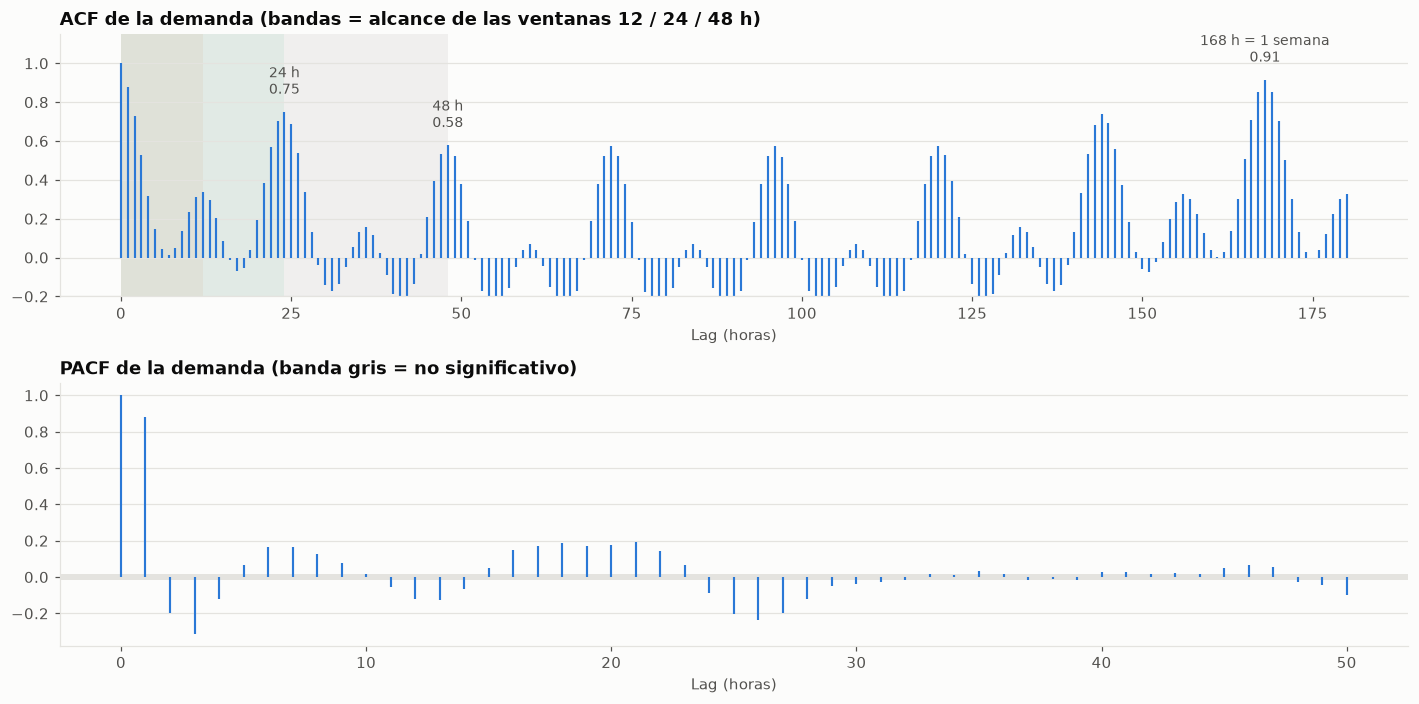

1      0.879
2      0.729
3      0.526
6      0.042
12     0.338
23     0.704
24     0.749
25     0.689
48     0.577
72     0.574
144    0.740
168    0.915
Name: ACF, dtype: float64

In [7]:
serie = train.demanda.dropna()
a = acf(serie, nlags=180)
p = pacf(serie, nlags=50)

fig, ax = plt.subplots(2, 1, figsize=(13, 6.5))
ax[0].vlines(range(len(a)), 0, a, color=AZUL, linewidth=1.4)
for lag, nombre in [(24, "24 h"), (48, "48 h"), (168, "168 h = 1 semana")]:
    ax[0].annotate(f"{nombre}\n{a[lag]:.2f}", (lag, a[lag]), xytext=(0, 12), textcoords="offset points",
                   ha="center", fontsize=9, color=TINTA_2)
for n, color in [(12, NARANJA), (24, AQUA), (48, TINTA_2)]:
    ax[0].axvspan(0, n, color=color, alpha=0.07, linewidth=0)
ax[0].set_title("ACF de la demanda (bandas = alcance de las ventanas 12 / 24 / 48 h)")
ax[0].set_ylim(-0.2, 1.15); ax[0].set_xlabel("Lag (horas)")

ax[1].vlines(range(len(p)), 0, p, color=AZUL, linewidth=1.4)
ax[1].axhspan(-1.96 / np.sqrt(len(serie)), 1.96 / np.sqrt(len(serie)), color=REJILLA, linewidth=0)
ax[1].set_title("PACF de la demanda (banda gris = no significativo)"); ax[1].set_xlabel("Lag (horas)")
plt.tight_layout(); plt.savefig(FIG / "02_acf_pacf.png"); plt.show()

pd.Series({k: round(a[k], 3) for k in [1, 2, 3, 6, 12, 23, 24, 25, 48, 72, 144, 168]}, name="ACF")

**Lectura (y consecuencias para la ventana):**
- **Lag 1 = 0.88:** la hora anterior es el mejor predictor individual. Por eso cualquier ventana, incluso la de 12 h, ya contiene mucha información.
- **Lag 6 ≈ 0 y lag 12 ≈ 0.34:** la serie "se opone a sí misma" a media jornada, por los picos y valles del día.
- **Lag 24 = 0.75:** la misma hora de ayer se parece mucho a la de hoy. **Una ventana de 12 h no alcanza a ver la misma hora del día anterior**; las de 24 y 48 h sí. *Hipótesis: 24 y 48 h deberían superar a 12 h.*
- **Lag 168 = 0.92 (¡el más alto después del lag 1!):** el patrón semanal es muy fuerte. Ninguna ventana del taller llega a 168 h. Por eso es clave darle al modelo variables de calendario (`dia_semana`, `fin_semana`): le "cuentan" en qué punto de la semana está sin necesidad de mirar 7 días atrás.
- **PACF:** casi toda la información nueva está en los lags 1–3 y alrededor de 17–27. Ir de 24 a 48 h probablemente aporte **poco** extra. *Hipótesis: 48 h ≈ 24 h, con más costo y más riesgo de sobreajuste.*

Estas hipótesis se comprobarán en la Fase 6. El EDA nos da qué esperar, y si el resultado difiere, habrá que explicar por qué.

## 6. Relación de cada variable con la demanda

### 6.1 Correlación global

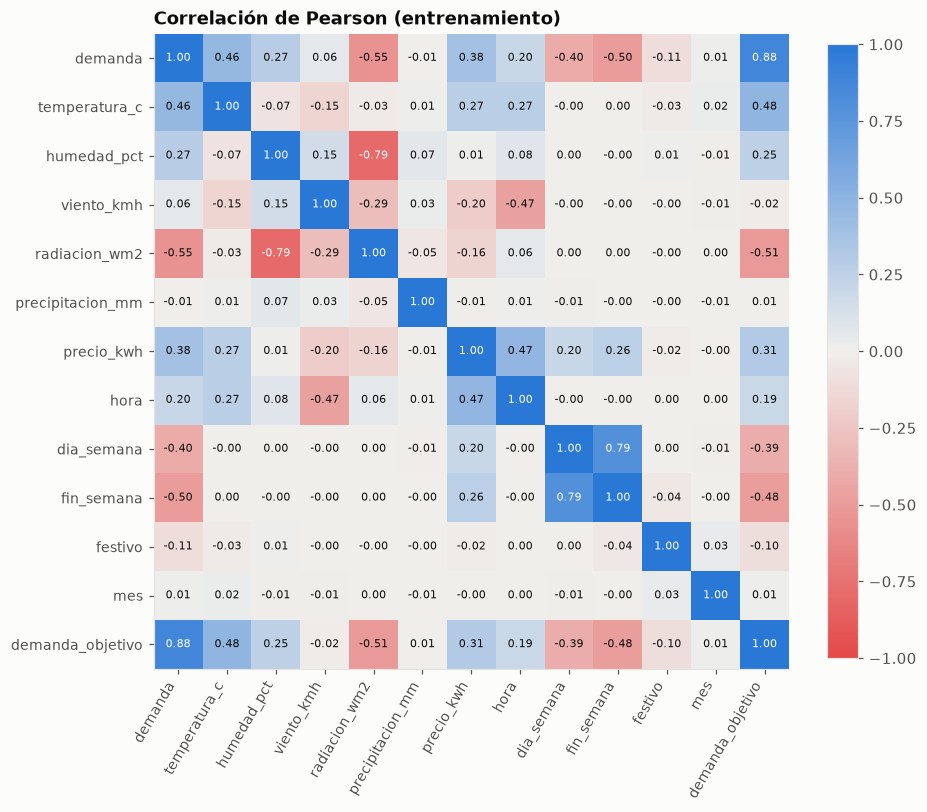

In [8]:
VARS = ["demanda", "temperatura_c", "humedad_pct", "viento_kmh", "radiacion_wm2",
        "precipitacion_mm", "precio_kwh", "hora", "dia_semana", "fin_semana", "festivo", "mes"]
corr = train[VARS + ["demanda_objetivo"]].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap=cmap_divergente(), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(len(corr)), corr.index, fontsize=9); ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.6 else "#0b0b0b")
ax.set_title("Correlación de Pearson (entrenamiento)")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.savefig(FIG / "02_matriz_correlacion.png"); plt.show()

### 6.2 ¡Cuidado! La correlación global puede engañar

La radiación solar tiene correlación **−0.51** con la demanda. ¿Significa que el sol reduce el consumo? Pensemos: la radiación es máxima al **mediodía**, justo cuando la demanda tiene su **valle**. La correlación negativa puede venir solo de la **hora**, que es un factor común a ambas variables (una *variable de confusión*).

**Prueba:** calculamos la correlación **dentro de cada hora**, comparando solo mediodías con mediodías. Así eliminamos el efecto de la hora.

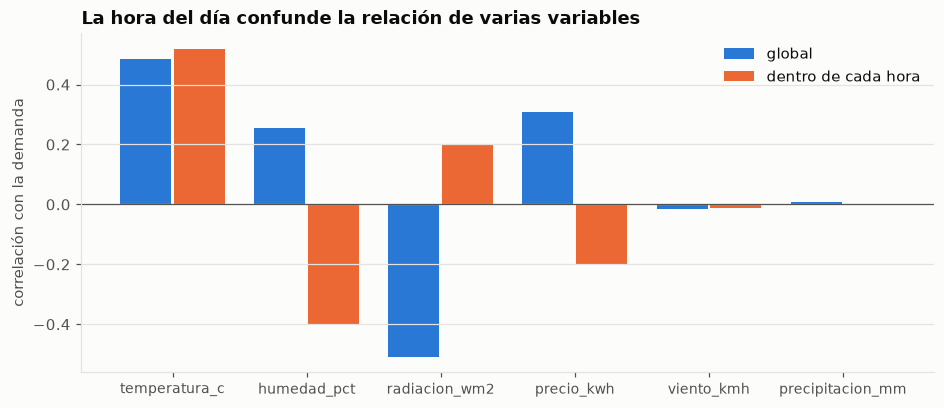

,global,dentro de cada hora (mediana)
temperatura_c,0.484,0.520
humedad_pct,0.254,-0.403
radiacion_wm2,-0.508,0.201
precio_kwh,0.309,-0.203
viento_kmh,-0.017,-0.011
precipitacion_mm,0.008,-0.003


In [9]:
exog = ["temperatura_c", "humedad_pct", "radiacion_wm2", "precio_kwh", "viento_kmh", "precipitacion_mm"]
comp = pd.DataFrame({
    "global": [train[v].corr(train.demanda_objetivo) for v in exog],
    "dentro de cada hora (mediana)": [train.groupby("hora").apply(
        lambda g: g[v].corr(g.demanda_objetivo), include_groups=False).median() for v in exog],
}, index=exog).round(3)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(exog)); w = 0.38
ax.bar(x - w/2 - 0.01, comp.iloc[:, 0], w, color=AZUL, label="global")
ax.bar(x + w/2 + 0.01, comp.iloc[:, 1], w, color=NARANJA, label="dentro de cada hora")
ax.axhline(0, color=TINTA_2, linewidth=0.8)
ax.set_xticks(x, exog, fontsize=9); ax.set_ylabel("correlación con la demanda")
ax.set_title("La hora del día confunde la relación de varias variables"); ax.legend()
plt.savefig(FIG / "02_correlacion_confusion.png"); plt.show()
comp

**¡Tres variables cambian de signo!**

| Variable | Global | Dentro de cada hora | Interpretación |
|---|---|---|---|
| Radiación | −0.51 | **+0.20** | A la *misma hora*, más sol → más calor → más demanda. El signo global negativo era un efecto de la hora. |
| Humedad | +0.25 | **−0.40** | La humedad es alta de noche (cuando la demanda nocturna es alta). A la misma hora, más humedad suele significar día nublado o fresco. |
| Precio | +0.31 | **−0.20** | Global positivo porque precio y demanda siguen el mismo ciclo diario. |
| Temperatura | +0.48 | **+0.52** | Relación robusta: se mantiene en ambos análisis. **Es la variable exógena más importante.** |
| Viento, precipitación | ≈ 0 | ≈ 0 | Sin relación detectable. |

**Lección:** no se debe elegir variables solo por su correlación global. Esto también justifica usar una red neuronal en lugar de una regresión lineal simple: la red puede aprender **interacciones** como "radiación × hora del día".

### 6.3 Relaciones no lineales: información mutua

Pearson solo detecta relaciones **lineales**. La **información mutua** (MI) detecta cualquier tipo de dependencia: vale 0 si las variables son independientes y crece cuanto más informa una sobre la otra.

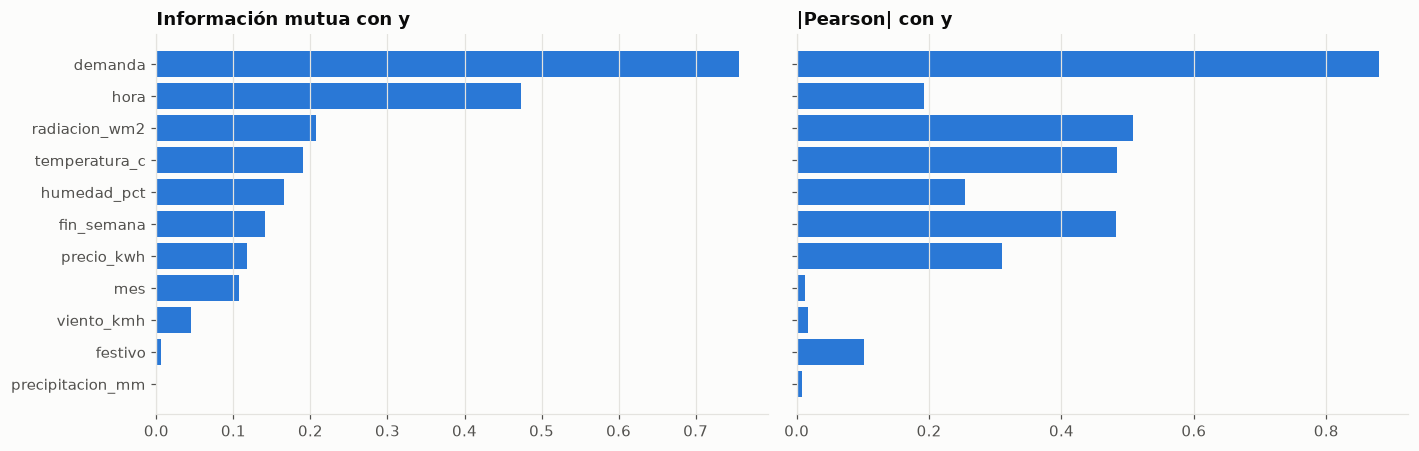

In [10]:
cols_mi = ["demanda", "hora", "radiacion_wm2", "temperatura_c", "humedad_pct", "fin_semana",
           "precio_kwh", "mes", "viento_kmh", "festivo", "precipitacion_mm"]
datos_mi = train[cols_mi + ["demanda_objetivo"]].dropna()
mi = pd.Series(mutual_info_regression(datos_mi[cols_mi], datos_mi.demanda_objetivo, random_state=0),
               index=cols_mi).sort_values()
pear = train[cols_mi].corrwith(train.demanda_objetivo).abs().reindex(mi.index)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
ax[0].barh(mi.index, mi.values, color=AZUL); ax[0].set_title("Información mutua con y")
ax[1].barh(pear.index, pear.values, color=AZUL); ax[1].set_title("|Pearson| con y")
for a_ in ax: a_.grid(axis="x"); a_.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(FIG / "02_informacion_mutua.png"); plt.show()

**Hallazgo:** la **hora** tiene correlación de Pearson baja (0.19), pero información mutua alta (0.47), la segunda mayor. La relación hora → demanda es fuerte pero **no lineal**: sube, baja y vuelve a subir.

Esto justifica la **codificación cíclica** (seno/coseno) que haremos en la Fase 3. Como número, la hora 23 y la hora 0 parecen lejanas (23 vs. 0), pero son consecutivas.

`precipitacion_mm` (MI = 0) y `viento_kmh` (MI ≈ 0.05) confirman que **no aportan información**.

### 6.4 La forma de la relación con la temperatura

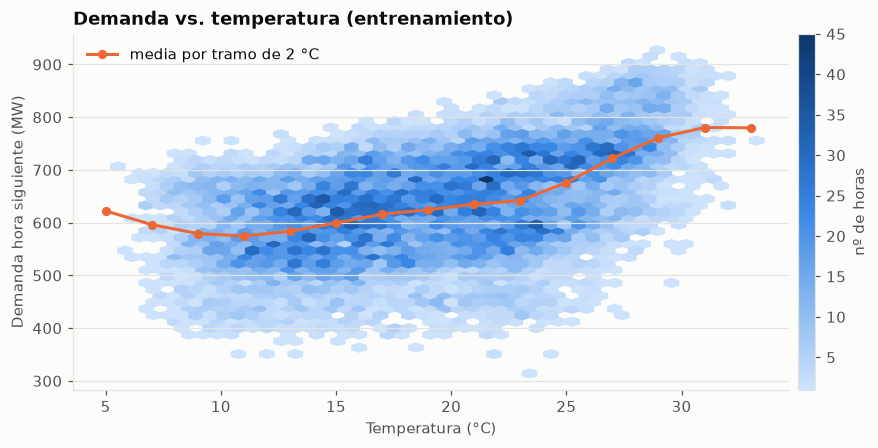

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.2))
hb = ax.hexbin(train.temperatura_c, train.demanda_objetivo, gridsize=45, cmap=cmap_secuencial(), mincnt=1)
bins = pd.cut(train.temperatura_c, np.arange(0, 38, 2))
media = train.groupby(bins, observed=True).demanda_objetivo.mean()
ax.plot([i.mid for i in media.index], media.values, color=NARANJA, marker="o", markersize=5,
        label="media por tramo de 2 °C")
ax.set_xlabel("Temperatura (°C)"); ax.set_ylabel("Demanda hora siguiente (MW)")
ax.set_title("Demanda vs. temperatura (entrenamiento)"); ax.legend(loc="upper left")
plt.colorbar(hb, ax=ax, label="nº de horas", pad=0.01)
plt.savefig(FIG / "02_demanda_vs_temperatura.png"); plt.show()

La curva tiene forma de **"J"**: es casi plana entre 8 y 16 °C, sube con fuerza por encima de ~20 °C (aire acondicionado) y sube un poco en el frío extremo (calefacción). Una relación así **no es lineal**, otro argumento para usar una red neuronal.

## 7. ¿Se parecen train, validación y test?

Es una pregunta crucial para interpretar correctamente las métricas finales.

,count,mean,std,min,max
split,,,,,
train,13104,636.1,98.4,314.1,927.3
validación,2208,655.9,101.6,370.2,913.7
test,2207,600.3,79.8,375.1,799.4


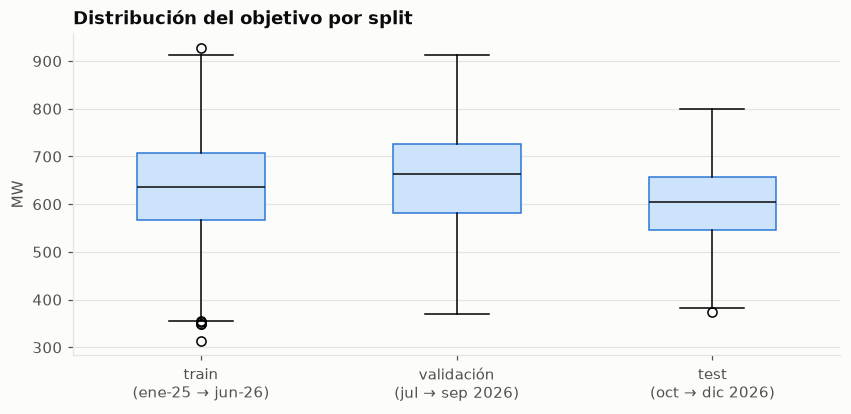

In [12]:
resumen = df.groupby("split").demanda_objetivo.agg(["count", "mean", "std", "min", "max"]).reindex(
    ["train", "validación", "test"]).round(1)
display(resumen)

fig, ax = plt.subplots(figsize=(9, 3.8))
datos = [df.loc[df.split == s, "demanda_objetivo"].dropna() for s in ["train", "validación", "test"]]
bp = ax.boxplot(datos, tick_labels=["train\n(ene-25 → jun-26)", "validación\n(jul → sep 2026)", "test\n(oct → dic 2026)"],
                patch_artist=True, widths=0.5, medianprops={"color": "#0b0b0b"})
for caja in bp["boxes"]:
    caja.set_facecolor("#cde2fb"); caja.set_edgecolor(AZUL)
ax.set_ylabel("MW"); ax.set_title("Distribución del objetivo por split")
plt.savefig(FIG / "02_distribucion_splits.png"); plt.show()

**Implicación importante para el R²:** el test (oct–dic) tiene **menor variabilidad** (desv. ≈ 80 MW) que train y validación (≈ 100 MW).

Recordemos que R² = 1 − (error del modelo / variabilidad de los datos). Con menos variabilidad en el denominador, **el mismo error absoluto produce un R² más bajo**. Por eso:
- el R² de test **no debe compararse** directamente con el de validación;
- para comparar periodos usaremos sobre todo **MAE y RMSE** (en MW), y siempre contra los **baselines** sobre el mismo test.

Además, la **validación (jul–sep) incluye el verano** con los picos más altos, mientras que el test no los tiene. El modelo se elige con un periodo "difícil" y se evalúa en uno más "tranquilo". Lo comentaremos en el análisis de generalización.

## 8. Efecto de la limpieza en la distribución

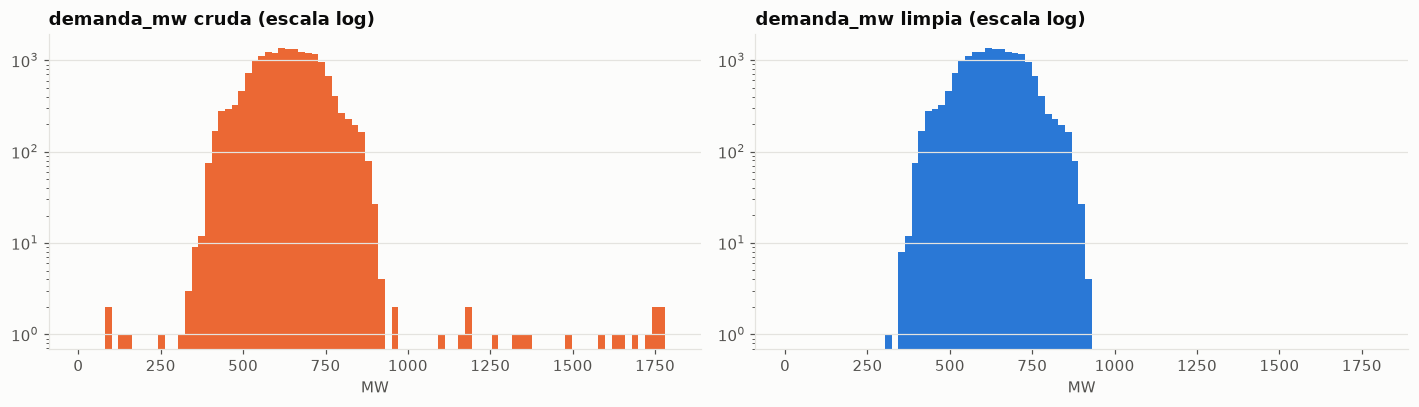

In [13]:
crudo = pd.read_csv(RAIZ / "data/raw/dataset_demanda_energia_LSTM_2025_2026.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
bins = np.linspace(0, 1800, 90)
ax[0].hist(crudo.demanda_mw, bins=bins, color=NARANJA); ax[0].set_yscale("log")
ax[0].set_title("demanda_mw cruda (escala log)"); ax[0].set_xlabel("MW")
ax[1].hist(df.demanda_mw.dropna(), bins=bins, color=AZUL); ax[1].set_yscale("log")
ax[1].set_title("demanda_mw limpia (escala log)"); ax[1].set_xlabel("MW")
plt.tight_layout(); plt.savefig(FIG / "02_distribucion_limpieza.png"); plt.show()

La escala logarítmica hace visibles los pocos valores imposibles (≈ 100 MW y > 1 000 MW) de la serie cruda. Tras la limpieza desaparecen, y **el rango real (314–927 MW) queda intacto**.

## 9. Conclusiones → decisiones para la Fase 3

| # | Hallazgo | Decisión |
|---|---|---|
| 1 | ACF: lag 1 = 0.88, lag 24 = 0.75, lag 168 = 0.92 | Probar 12/24/48 h. Hipótesis: 24 ≈ 48 > 12 |
| 2 | Patrón semanal fuerte, pero fuera del alcance de las ventanas | Incluir `dia_semana` (cíclica) y `fin_semana` como entradas |
| 3 | Hora: relación fuerte y no lineal | Codificación cíclica sin/cos de `hora` |
| 4 | Temperatura: relación robusta en forma de "J" | Variable exógena clave |
| 5 | Radiación, humedad y precio cambian de signo según la hora | Se mantienen: la red puede aprender la interacción con la hora |
| 6 | Viento y precipitación sin información (MI ≈ 0) | **Se excluyen** del modelo principal; se verificará con una ablación |
| 7 | `periodo_dia` es redundante con `hora` | Se excluye |
| 8 | Solo 8 festivos en train | Se mantiene `festivo`, pero se reporta como limitación |
| 9 | Test con menor variabilidad que train/val | Interpretar el R² con cuidado y comparar siempre contra baselines |
| 10 | Sin tendencia entre años | No hace falta quitar tendencia; basta con normalizar |